In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

PATH = r'C:\Users\Никита\Skillfactory\Project workshop (hackathon)\df_clean.csv'
df = pd.read_csv(PATH, low_memory=False)
df['visit_date'] = pd.to_datetime(df['visit_date'])
print(df.shape)
df.head(3)

(1860042, 18)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0


In [3]:
# Feature Engineering — создаём новые признаки
# Временные признаки
df['month'] = df['visit_date'].dt.month
df['day_of_week'] = df['visit_date'].dt.dayofweek  # 0=пн, 6=вс
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Признаки из visit_time 
df['visit_time'] = pd.to_numeric(df['visit_time'], errors='coerce').fillna(0)
df['hour'] = (df['visit_time'] // 3600).astype(int).clip(0, 23)
df['is_work_hours'] = df['hour'].between(9, 18).astype(int)

# Признаки из visit_number
df['is_first_visit'] = (df['visit_number'] == 1).astype(int)
df['is_repeat_visit'] = (df['visit_number'] > 1).astype(int)
df['visit_number_log'] = np.log1p(df['visit_number'])

# Признаки изutm_medium
df['is_cpa']      = (df['utm_medium'] == 'cpa').astype(int)
df['is_smm']      = (df['utm_medium'] == 'smm').astype(int)
df['is_referral'] = (df['utm_medium'] == 'referral').astype(int)
df['is_organic']  = (df['utm_medium'] == 'organic').astype(int)
df['is_cpc']      = (df['utm_medium'] == 'cpc').astype(int)
df['is_push']     = (df['utm_medium'] == 'push').astype(int)

# Признаки из device
df['is_desktop'] = (df['device_category'] == 'desktop').astype(int)
df['is_mobile']  = (df['device_category'] == 'mobile').astype(int)

# Признаки из geo
df['is_moscow']  = df['geo_city'].str.lower().str.contains('moscow|moskva', na=False).astype(int)

# Target encoding для utm_medium (конверсия по каналу)
medium_conv = df.groupby('utm_medium')['target'].mean()
df['utm_medium_conv'] = df['utm_medium'].map(medium_conv)

# Target encoding для utm_source
source_conv = df.groupby('utm_source')['target'].mean()
df['utm_source_conv'] = df['utm_source'].map(source_conv)

# Target encoding для geo_city
city_conv = df.groupby('geo_city')['target'].mean()
df['city_conv'] = df['geo_city'].map(city_conv)

print('Итоговый размер датасета:', df.shape)

Итоговый размер датасета: (1860042, 38)


In [4]:
# Подготовка фичей для модели
feature_cols = [
    # Числовые
    'visit_number', 'visit_number_log',
    'month', 'day_of_week', 'hour',
    # Бинарные из visit_number
    'is_first_visit', 'is_repeat_visit',
    # Бинарные из устройства
    'is_desktop', 'is_mobile',
    # Бинарные из utm_medium
    'is_cpa', 'is_smm', 'is_referral', 'is_organic', 'is_cpc', 'is_push',
    # Бинарные из времени
    'is_weekend', 'is_work_hours',
    # Бинарные из гео
    'is_moscow',
    # Target encoding
    'utm_medium_conv', 'utm_source_conv', 'city_conv',
]

X = df[feature_cols].fillna(0)
y = df['target']

print('Признаки:', X.shape)
print(y.value_counts())
# Разбивка на train/test (80/20), стратификация по target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Признаки: (1860042, 21)
target
0    1843320
1      16722
Name: count, dtype: int64

Train: (1488033, 21), Test: (372009, 21)


In [5]:
# Baseline — Логистическая регрессия
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
print(f'Логистическая регрессия ROC-AUC: {lr_auc:.4f}')

c:\Users\Никита\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Логистическая регрессия ROC-AUC: 0.6734


In [6]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print(f'Random Forest ROC-AUC: {rf_auc:.4f}')

Random Forest ROC-AUC: 0.7072


In [7]:
# LightGBM — основная модель
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
print(f'LightGBM ROC-AUC: {lgbm_auc:.4f}')
best_proba = lgbm_proba
best_name = 'LightGBM'
best_auc = lgbm_auc

LightGBM ROC-AUC: 0.7191


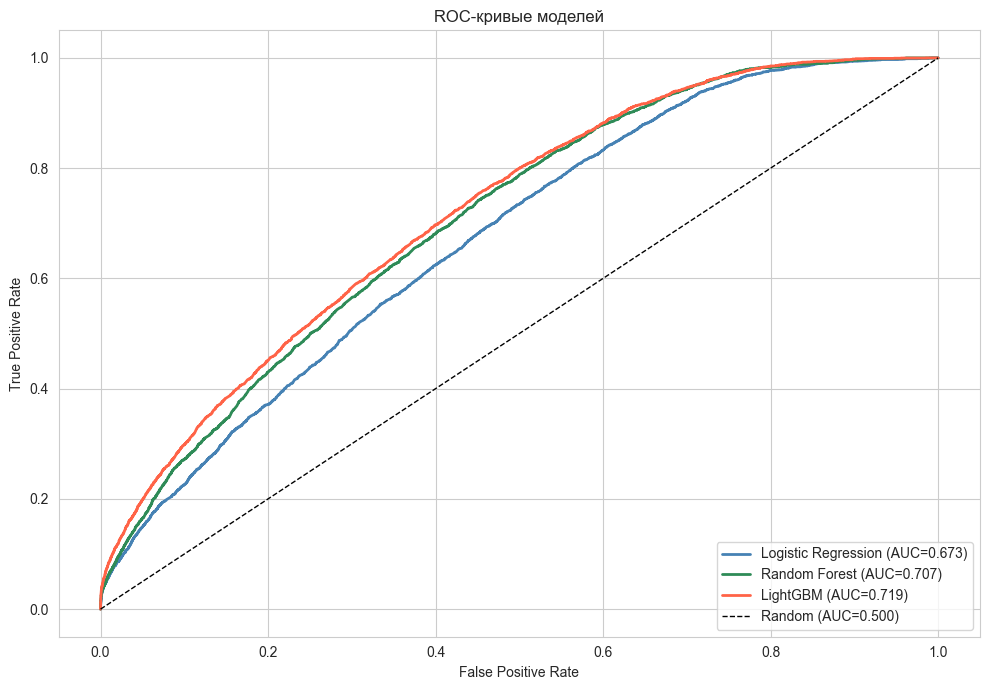

In [8]:
# Сравнение ROC-кривых всех моделей
fig, ax = plt.subplots(figsize=(10, 7))

for proba, name, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.3f})', 'steelblue'),
    (rf_proba, f'Random Forest (AUC={rf_auc:.3f})', 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=name, color=color, lw=2)


fpr, tpr, _ = roc_curve(y_test, lgbm_proba)
ax.plot(fpr, tpr, label=f'LightGBM (AUC={lgbm_auc:.3f})', color='tomato', lw=2)


ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые моделей')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

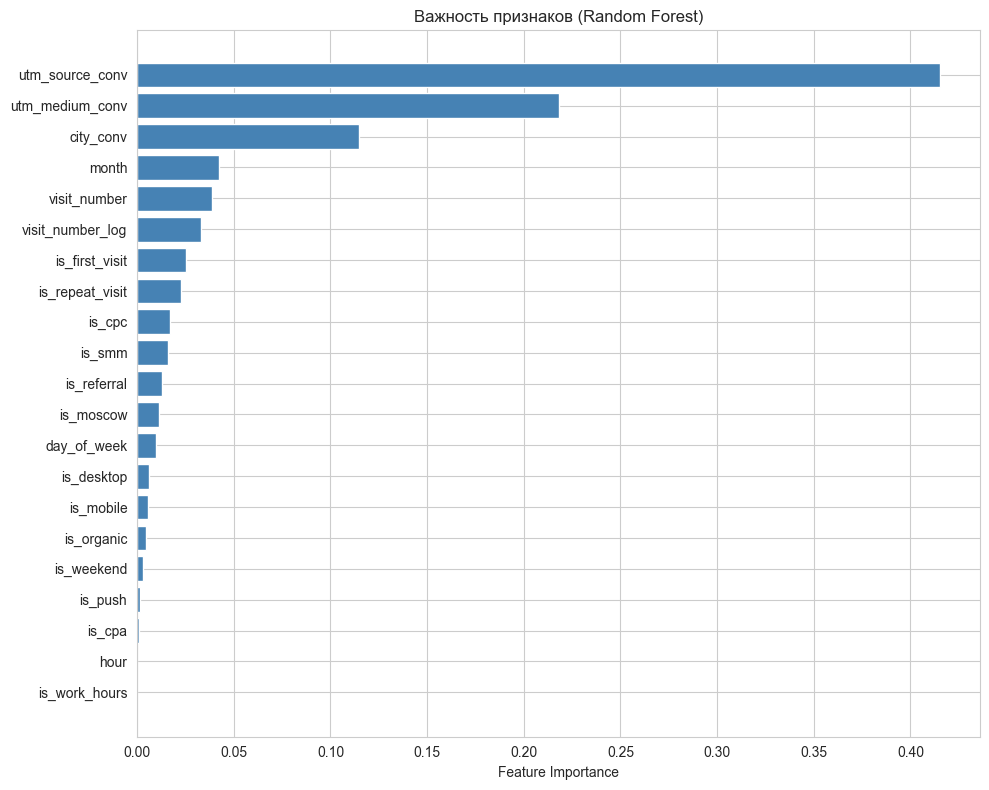


Топ-10 признаков:
         feature  importance
 utm_source_conv    0.415200
 utm_medium_conv    0.218371
       city_conv    0.114636
           month    0.042212
    visit_number    0.038798
visit_number_log    0.033106
  is_first_visit    0.025515
 is_repeat_visit    0.022528
          is_cpc    0.017260
          is_smm    0.015740


In [9]:
# Важность признаков — Random Forest
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_title('Важность признаков (Random Forest)')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
 
 
print('\nТоп-10 признаков:')
print(feat_imp.head(10).to_string(index=False))

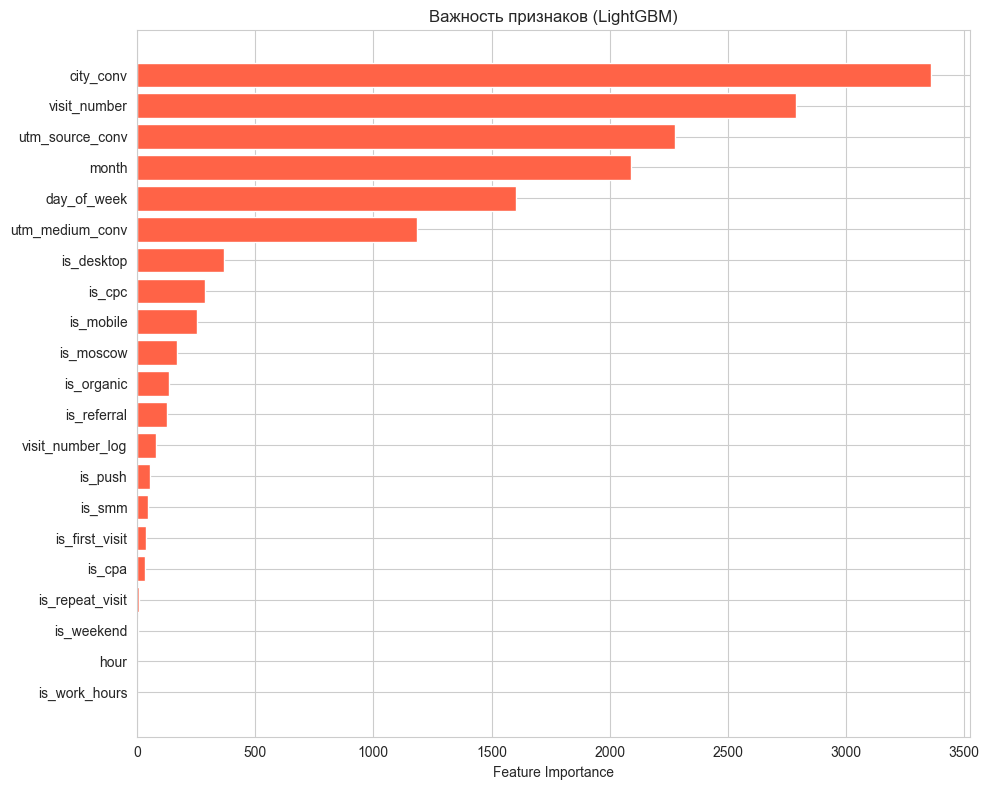


Топ-10 признаков LightGBM:
        feature  importance
      city_conv        3358
   visit_number        2790
utm_source_conv        2276
          month        2092
    day_of_week        1604
utm_medium_conv        1183
     is_desktop         368
         is_cpc         287
      is_mobile         255
      is_moscow         167


In [10]:
# Важность признаков LightGBM
lgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(lgb_imp['feature'], lgb_imp['importance'], color='tomato')
ax.set_title('Важность признаков (LightGBM)')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nТоп-10 признаков LightGBM:')
print(lgb_imp.head(10).to_string(index=False))


In [11]:
# Итоговое сравнение моделей
print('Итоговое сравнение моделей:')
print(f'Логистическая регрессия:  ROC-AUC = {lr_auc:.4f}')
print(f'Random Forest:            ROC-AUC = {rf_auc:.4f}')
print(f'LightGBM:                 ROC-AUC = {lgbm_auc:.4f}')
print(f'Целевой показатель:       ROC-AUC >= 0.65')

# Сохраняем лучшую модель
import pickle
MODEL_PATH = r'C:\Users\Никита\Skillfactory\Project workshop (hackathon)\best_model.pkl'
best_model = lgbm

with open(MODEL_PATH, 'wb') as f:
    pickle.dump({'model': best_model, 'features': feature_cols}, f)


Итоговое сравнение моделей:
Логистическая регрессия:  ROC-AUC = 0.6734
Random Forest:            ROC-AUC = 0.7072
LightGBM:                 ROC-AUC = 0.7191
Целевой показатель:       ROC-AUC >= 0.65
